In [1]:
!pip install sentence-transformers
!pip install faiss-cpu
!pip install rank-bm25
!pip install nltk
!pip install spacy
!pip install scikit-learn
!pip install numpy
!pip install pandas
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import time
import faiss
import matplotlib.pyplot as plt
import nltk

nltk.download('punkt')
nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
from sklearn.metrics.pairwise import cosine_similarity


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_csv('dataset.csv')

print(f'Taille du dataset : {len(df)} entrées')
print(f'Colonnes : {list(df.columns)}')
print(f'\nDistribution des labels :')
print(df['label'].value_counts())

df.head()

Taille du dataset : 500 entrées
Colonnes : ['id', 'text', 'label', 'attack_type', 'risk_level', 'language', 'source_type', 'contains_url', 'suspicious_keywords', 'explanation', 'synthetic_generated']

Distribution des labels :
label
phishing      288
legitimate    212
Name: count, dtype: int64


,id,text,label,attack_type,risk_level,language,source_type,contains_url,suspicious_keywords,explanation,synthetic_generated
0,1,Your order has been shipped successfully.,legitimate,normal,low,en,sms,0,none,No suspicious indicators detected. Message app...,1
1,2,Your CIH Bank account has been suspended. Veri...,phishing,banking,critical,en,url,1,"urgent, security, delivery","Contains urgency language, suspicious links, c...",1
2,3,تحذير عاجل: قم بتأكيد كلمة المرور الخاصة بك ال...,phishing,banking,critical,ar,url,1,"click, delivery, suspended","Contains urgency language, suspicious links, c...",1
3,4,Urgent! Confirm your password now to avoid acc...,phishing,job_scam,critical,en,url,1,"confirm, suspended, verify","Contains urgency language, suspicious links, c...",1
4,5,Vous avez gagné 2 BTC. Réclamez votre récompen...,phishing,banking,medium,fr,social_media,1,"confirm, suspended, bitcoin","Contains urgency language, suspicious links, c...",1


In [4]:

stop_words_en = set(stopwords.words('english'))
stop_words_fr = set(stopwords.words('french'))


stop_words_ar = set([
    'في', 'من', 'على', 'إلى', 'عن', 'مع', 'هذا', 'هذه', 'التي', 'الذي',
    'كان', 'كانت', 'يكون', 'أن', 'لا', 'ما', 'لم', 'قد', 'كل', 'هو',
    'هي', 'نحن', 'أنت', 'أنا', 'هم', 'لقد', 'لكن', 'أو', 'بعد', 'قبل',
    'حتى', 'عند', 'بين', 'خلال', 'تم', 'يتم', 'عبر', 'وفي', 'وعلى'
])

stop_words = stop_words_en.union(stop_words_fr).union(stop_words_ar)
print(f'Total stopwords : {len(stop_words)} (EN: {len(stop_words_en)}, FR: {len(stop_words_fr)}, AR: {len(stop_words_ar)})')

def preprocess_text(text):
    text = str(text)
    text = text.lower()
    # Garder lettres FR, EN, AR + espaces
    text = re.sub(r'[^a-zA-ZÀ-ÿ\u0600-\u06FF\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

Total stopwords : 385 (EN: 198, FR: 157, AR: 39)


In [5]:
documents = df['text'].tolist()
labels = df['label'].tolist()

processed_docs = [preprocess_text(doc) for doc in documents]

print('Prétraitement terminé')
print('\nExemples :')
for i in range(3):
    print(f'  Original  : {documents[i][:80]}')
    print(f'  Traité    : {processed_docs[i][:80]}')
    print()

Prétraitement terminé

Exemples :
  Original  : Your order has been shipped successfully.
  Traité    : order shipped successfully

  Original  : Your CIH Bank account has been suspended. Verify immediately: https://woods.net/
  Traité    : cih bank account suspended verify immediately httpswoodsnet

  Original  : تحذير عاجل: قم بتأكيد كلمة المرور الخاصة بك الآن: https://gonzalez.com/
  Traité    : تحذير عاجل قم بتأكيد كلمة المرور الخاصة بك الآن httpsgonzalezcom



In [6]:
model_name = 'all-MiniLM-L6-v2'
model = SentenceTransformer(model_name)

print(f'Modèle chargé : {model_name}')

t0 = time.time()
embeddings = model.encode(processed_docs, show_progress_bar=True)
t1 = time.time()

print(f'\nEmbeddings générés')
print(f'   Shape : {embeddings.shape}')
print(f'   Temps : {t1 - t0:.2f}s')

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Modèle chargé : all-MiniLM-L6-v2


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Embeddings générés
   Shape : (500, 384)
   Temps : 1.59s


In [7]:

dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings.astype('float32'))

print(f'Index FAISS créé')
print(f'   Dimension : {dimension}')
print(f'   Nb vecteurs indexés : {index.ntotal}')

Index FAISS créé
   Dimension : 384
   Nb vecteurs indexés : 500


In [8]:
def faiss_search(query_text, k=5):

    processed = preprocess_text(query_text)
    query_embedding = model.encode([processed]).astype('float32')
    distances, indices = index.search(query_embedding, k)
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        results.append({
            'index': idx,
            'text': documents[idx][:100],
            'label': labels[idx],
            'distance': round(float(dist), 4)
        })
    return results


query_test = 'Your bank account has been suspended. Verify now to avoid deletion.'
print(f'Requete : {query_test}')
print(f'\nTop-5 résultats FAISS :')
for r in faiss_search(query_test, k=5):
    print(f"  [{r['label'].upper():10}] dist={r['distance']} → {r['text']}")

Requete : Your bank account has been suspended. Verify now to avoid deletion.

Top-5 résultats FAISS :
  [PHISHING  ] dist=0.5871 → Your Attijariwafa Bank account has been suspended. Verify immediately: https://nguyen.biz/
  [PHISHING  ] dist=0.5956 → Your Attijariwafa Bank account has been suspended. Verify immediately: https://gillespie-mays.com/
  [PHISHING  ] dist=0.5992 → Your CIH Bank account has been suspended. Verify immediately: http://graham.info/
  [PHISHING  ] dist=0.6412 → Your CIH Bank account has been suspended. Verify immediately: https://shaw.com/
  [PHISHING  ] dist=0.6642 → Your Attijariwafa Bank account has been suspended. Verify immediately: https://nguyen.com/


In [9]:
tokenized_docs = [doc.split() for doc in processed_docs]
bm25 = BM25Okapi(tokenized_docs)

def bm25_search(query_text, k=5):
   
    processed = preprocess_text(query_text)
    tokenized_query = processed.split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:k]
    results = []
    for idx in top_indices:
        results.append({
            'index': int(idx),
            'text': documents[idx][:100],
            'label': labels[idx],
            'score': round(float(scores[idx]), 4)
        })
    return results

print(f'Requete : {query_test}')
print(f'\nTop-5 résultats BM25 :')
for r in bm25_search(query_test, k=5):
    print(f"  [{r['label'].upper():10}] score={r['score']} → {r['text']}")

Requete : Your bank account has been suspended. Verify now to avoid deletion.

Top-5 résultats BM25 :
  [PHISHING  ] score=9.8927 → Your Attijariwafa Bank account has been suspended. Verify immediately: https://nguyen.com/
  [PHISHING  ] score=9.8927 → Your CIH Bank account has been suspended. Verify immediately: https://shaw.com/
  [PHISHING  ] score=9.8927 → Your Attijariwafa Bank account has been suspended. Verify immediately: http://sims-bowers.org/
  [PHISHING  ] score=9.8927 → Your Attijariwafa Bank account has been suspended. Verify immediately: https://chandler.info/
  [PHISHING  ] score=9.8927 → Your CIH Bank account has been suspended. Verify immediately: http://graham.info/


In [10]:
def hybrid_search(query_text, k=5, alpha=0.5):
    
    n = len(documents)

    processed = preprocess_text(query_text)
    query_emb = model.encode([processed]).astype('float32')
    distances, indices = index.search(query_emb, n)
    faiss_scores = np.zeros(n)
    for dist, idx in zip(distances[0], indices[0]):
        faiss_scores[idx] = 1.0 / (1.0 + dist)

    tokenized_query = processed.split()
    bm25_raw = bm25.get_scores(tokenized_query)

    def normalize(arr):
        mn, mx = arr.min(), arr.max()
        return (arr - mn) / (mx - mn + 1e-9)

    faiss_norm = normalize(faiss_scores)
    bm25_norm = normalize(bm25_raw)

    hybrid_scores = alpha * faiss_norm + (1 - alpha) * bm25_norm
    top_indices = np.argsort(hybrid_scores)[::-1][:k]

    results = []
    for idx in top_indices:
        results.append({
            'index': int(idx),
            'text': documents[idx][:100],
            'label': labels[idx],
            'hybrid_score': round(float(hybrid_scores[idx]), 4),
            'faiss_score': round(float(faiss_norm[idx]), 4),
            'bm25_score': round(float(bm25_norm[idx]), 4)
        })
    return results

print(f'Requete : {query_test}')
print(f'\n Top-5 résultats HYBRIDE (α=0.5) :')
for r in hybrid_search(query_test, k=5, alpha=0.5):
    print(f"  [{r['label'].upper():10}] hybrid={r['hybrid_score']} (faiss={r['faiss_score']}, bm25={r['bm25_score']}) → {r['text']}")

Requete : Your bank account has been suspended. Verify now to avoid deletion.

 Top-5 résultats HYBRIDE (α=0.5) :
  [PHISHING  ] hybrid=1.0 (faiss=1.0, bm25=1.0) → Your Attijariwafa Bank account has been suspended. Verify immediately: https://nguyen.biz/
  [PHISHING  ] hybrid=0.9947 (faiss=0.9894, bm25=1.0) → Your Attijariwafa Bank account has been suspended. Verify immediately: https://gillespie-mays.com/
  [PHISHING  ] hybrid=0.9925 (faiss=0.9849, bm25=1.0) → Your CIH Bank account has been suspended. Verify immediately: http://graham.info/
  [PHISHING  ] hybrid=0.967 (faiss=0.9341, bm25=1.0) → Your CIH Bank account has been suspended. Verify immediately: https://shaw.com/
  [PHISHING  ] hybrid=0.9537 (faiss=0.9074, bm25=1.0) → Your Attijariwafa Bank account has been suspended. Verify immediately: https://nguyen.com/


In [11]:
models_to_benchmark = [
    'all-MiniLM-L6-v2',
    'paraphrase-multilingual-MiniLM-L12-v2',
    'all-mpnet-base-v2'
]

benchmark_results = []

sample_docs = processed_docs[:100]
phishing_sample = [d for d, l in zip(processed_docs[:100], labels[:100]) if l == 'phishing'][:5]
legit_sample = [d for d, l in zip(processed_docs[:100], labels[:100]) if l == 'legitimate'][:5]

for m_name in models_to_benchmark:
    print(f'Benchmarking : {m_name} ...')
    try:
        m = SentenceTransformer(m_name)

        t0 = time.time()
        emb = m.encode(sample_docs)
        t1 = time.time()
        encoding_time = round(t1 - t0, 3)

        
        emb_phish = m.encode(phishing_sample)
        emb_legit = m.encode(legit_sample)

        intra_sim = cosine_similarity(emb_phish).mean()
        inter_sim = cosine_similarity(emb_phish, emb_legit).mean()
        separation = round(float(intra_sim - inter_sim), 4)

        benchmark_results.append({
            'Modèle': m_name,
            'Dimension': emb.shape[1],
            'Temps (s)': encoding_time,
            'Sim. intra-phishing': round(float(intra_sim), 4),
            'Sim. inter-classe': round(float(inter_sim), 4),
            'Séparation (↑ mieux)': separation
        })
        print(f'  Dim={emb.shape[1]}, Temps={encoding_time}s, Séparation={separation}')
    except Exception as e:
        print(f'   Erreur : {e}')

df_benchmark = pd.DataFrame(benchmark_results)
print('\n Résultats du Benchmark :')
df_benchmark

Benchmarking : all-MiniLM-L6-v2 ...


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Dim=384, Temps=0.261s, Séparation=0.2875
Benchmarking : paraphrase-multilingual-MiniLM-L12-v2 ...


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Dim=384, Temps=0.245s, Séparation=0.3881
Benchmarking : all-mpnet-base-v2 ...


...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Dim=768, Temps=1.643s, Séparation=0.339

 Résultats du Benchmark :


,Modèle,Dimension,Temps (s),Sim. intra-phishing,Sim. inter-classe,Séparation (↑ mieux)
0,all-MiniLM-L6-v2,384,0.261,0.4496,0.1620,0.2875
1,paraphrase-multilingual-MiniLM-L12-v2,384,0.245,0.5344,0.1463,0.3881
2,all-mpnet-base-v2,768,1.643,0.5579,0.2188,0.3390


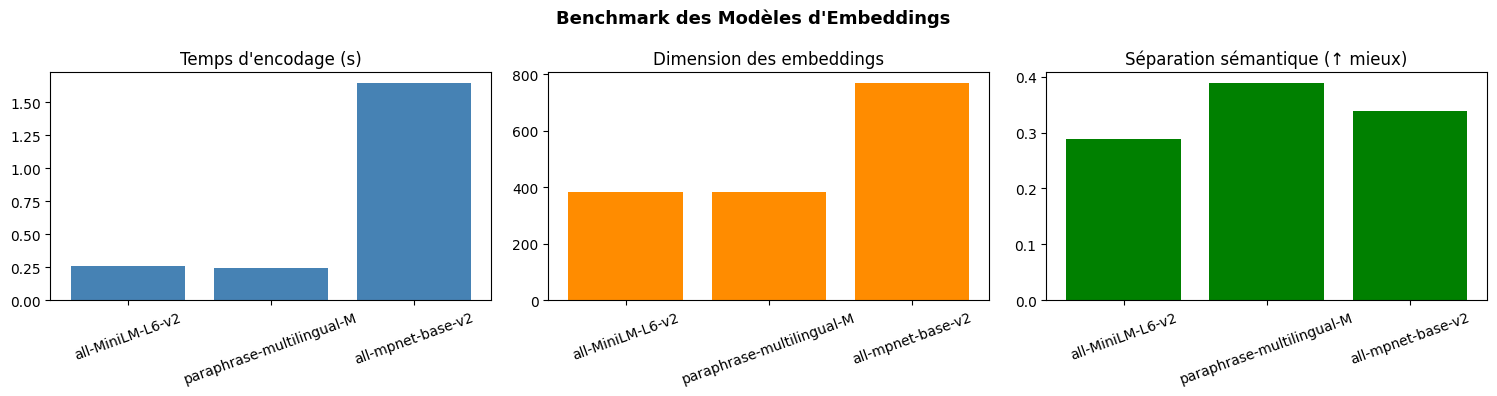

 Graphique sauvegardé : benchmark_embeddings.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modeles = [r['Modèle'].split('/')[-1][:25] for r in benchmark_results]

axes[0].bar(modeles, [r['Temps (s)'] for r in benchmark_results], color='steelblue')
axes[0].set_title('Temps d\'encodage (s)')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(modeles, [r['Dimension'] for r in benchmark_results], color='darkorange')
axes[1].set_title('Dimension des embeddings')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(modeles, [r['Séparation (↑ mieux)'] for r in benchmark_results], color='green')
axes[2].set_title('Séparation sémantique (↑ mieux)')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Benchmark des Modèles d\'Embeddings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Graphique sauvegardé : benchmark_embeddings.png')

In [13]:
def recall_at_k(retrieved_indices, relevant_indices, k):
    retrieved_k = set(retrieved_indices[:k])
    relevant = set(relevant_indices)
    if not relevant:
        return 0.0
    return len(retrieved_k & relevant) / len(relevant)

def precision_at_k(retrieved_indices, relevant_indices, k):
    retrieved_k = set(retrieved_indices[:k])
    relevant = set(relevant_indices)
    if k == 0:
        return 0.0
    return len(retrieved_k & relevant) / k

def mrr_score(retrieved_indices, relevant_indices):
    relevant = set(relevant_indices)
    for rank, idx in enumerate(retrieved_indices, start=1):
        if idx in relevant:
            return 1.0 / rank
    return 0.0


In [14]:

phishing_indices = [i for i, l in enumerate(labels) if l == 'phishing']
legit_indices = [i for i, l in enumerate(labels) if l == 'legitimate']

print(f'Phishing : {len(phishing_indices)} | Légitime : {len(legit_indices)}')

K_values = [1, 3, 5, 10]
methods = ['FAISS', 'BM25', 'Hybride']

eval_results = {m: {f'Recall@{k}': [] for k in K_values} for m in methods}
for m in methods:
    for k in K_values:
        eval_results[m][f'Precision@{k}'] = []
    eval_results[m]['MRR'] = []

sample_size = min(50, len(phishing_indices))
query_indices = phishing_indices[:sample_size]

for q_idx in query_indices:
    query_text = documents[q_idx]
    # Documents pertinents = les autres phishing (sauf lui-même)
    relevant = [i for i in phishing_indices if i != q_idx]

    processed = preprocess_text(query_text)
    q_emb = model.encode([processed]).astype('float32')
    _, faiss_idx = index.search(q_emb, 15)
    faiss_retrieved = [i for i in faiss_idx[0] if i != q_idx]


    tok_q = processed.split()
    bm25_scores = bm25.get_scores(tok_q)
    bm25_idx = np.argsort(bm25_scores)[::-1]
    bm25_retrieved = [i for i in bm25_idx if i != q_idx][:15]


    hybrid = hybrid_search(query_text, k=15)
    hybrid_retrieved = [r['index'] for r in hybrid if r['index'] != q_idx]

    for k in K_values:
        for method, retrieved in zip(methods, [faiss_retrieved, bm25_retrieved, hybrid_retrieved]):
            eval_results[method][f'Recall@{k}'].append(recall_at_k(retrieved, relevant, k))
            eval_results[method][f'Precision@{k}'].append(precision_at_k(retrieved, relevant, k))

    for method, retrieved in zip(methods, [faiss_retrieved, bm25_retrieved, hybrid_retrieved]):
        eval_results[method]['MRR'].append(mrr_score(retrieved, relevant))


summary = []
for method in methods:
    row = {'Méthode': method}
    for metric, values in eval_results[method].items():
        row[metric] = round(np.mean(values), 4)
    summary.append(row)

df_eval = pd.DataFrame(summary)
print('\n Résultats d\'évaluation :')
df_eval

Phishing : 288 | Légitime : 212

 Résultats d'évaluation :


,Méthode,Recall@1,Recall@3,Recall@5,Recall@10,Precision@1,Precision@3,Precision@5,Precision@10,MRR
0,FAISS,0.0035,0.0105,0.0174,0.0348,1.0,1.0,1.0,1.0,1.0
1,BM25,0.0035,0.0105,0.0174,0.0348,1.0,1.0,1.0,1.0,1.0
2,Hybride,0.0035,0.0105,0.0174,0.0348,1.0,1.0,1.0,1.0,1.0


C:\Users\User\AppData\Local\Temp\ipykernel_36704\797903234.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


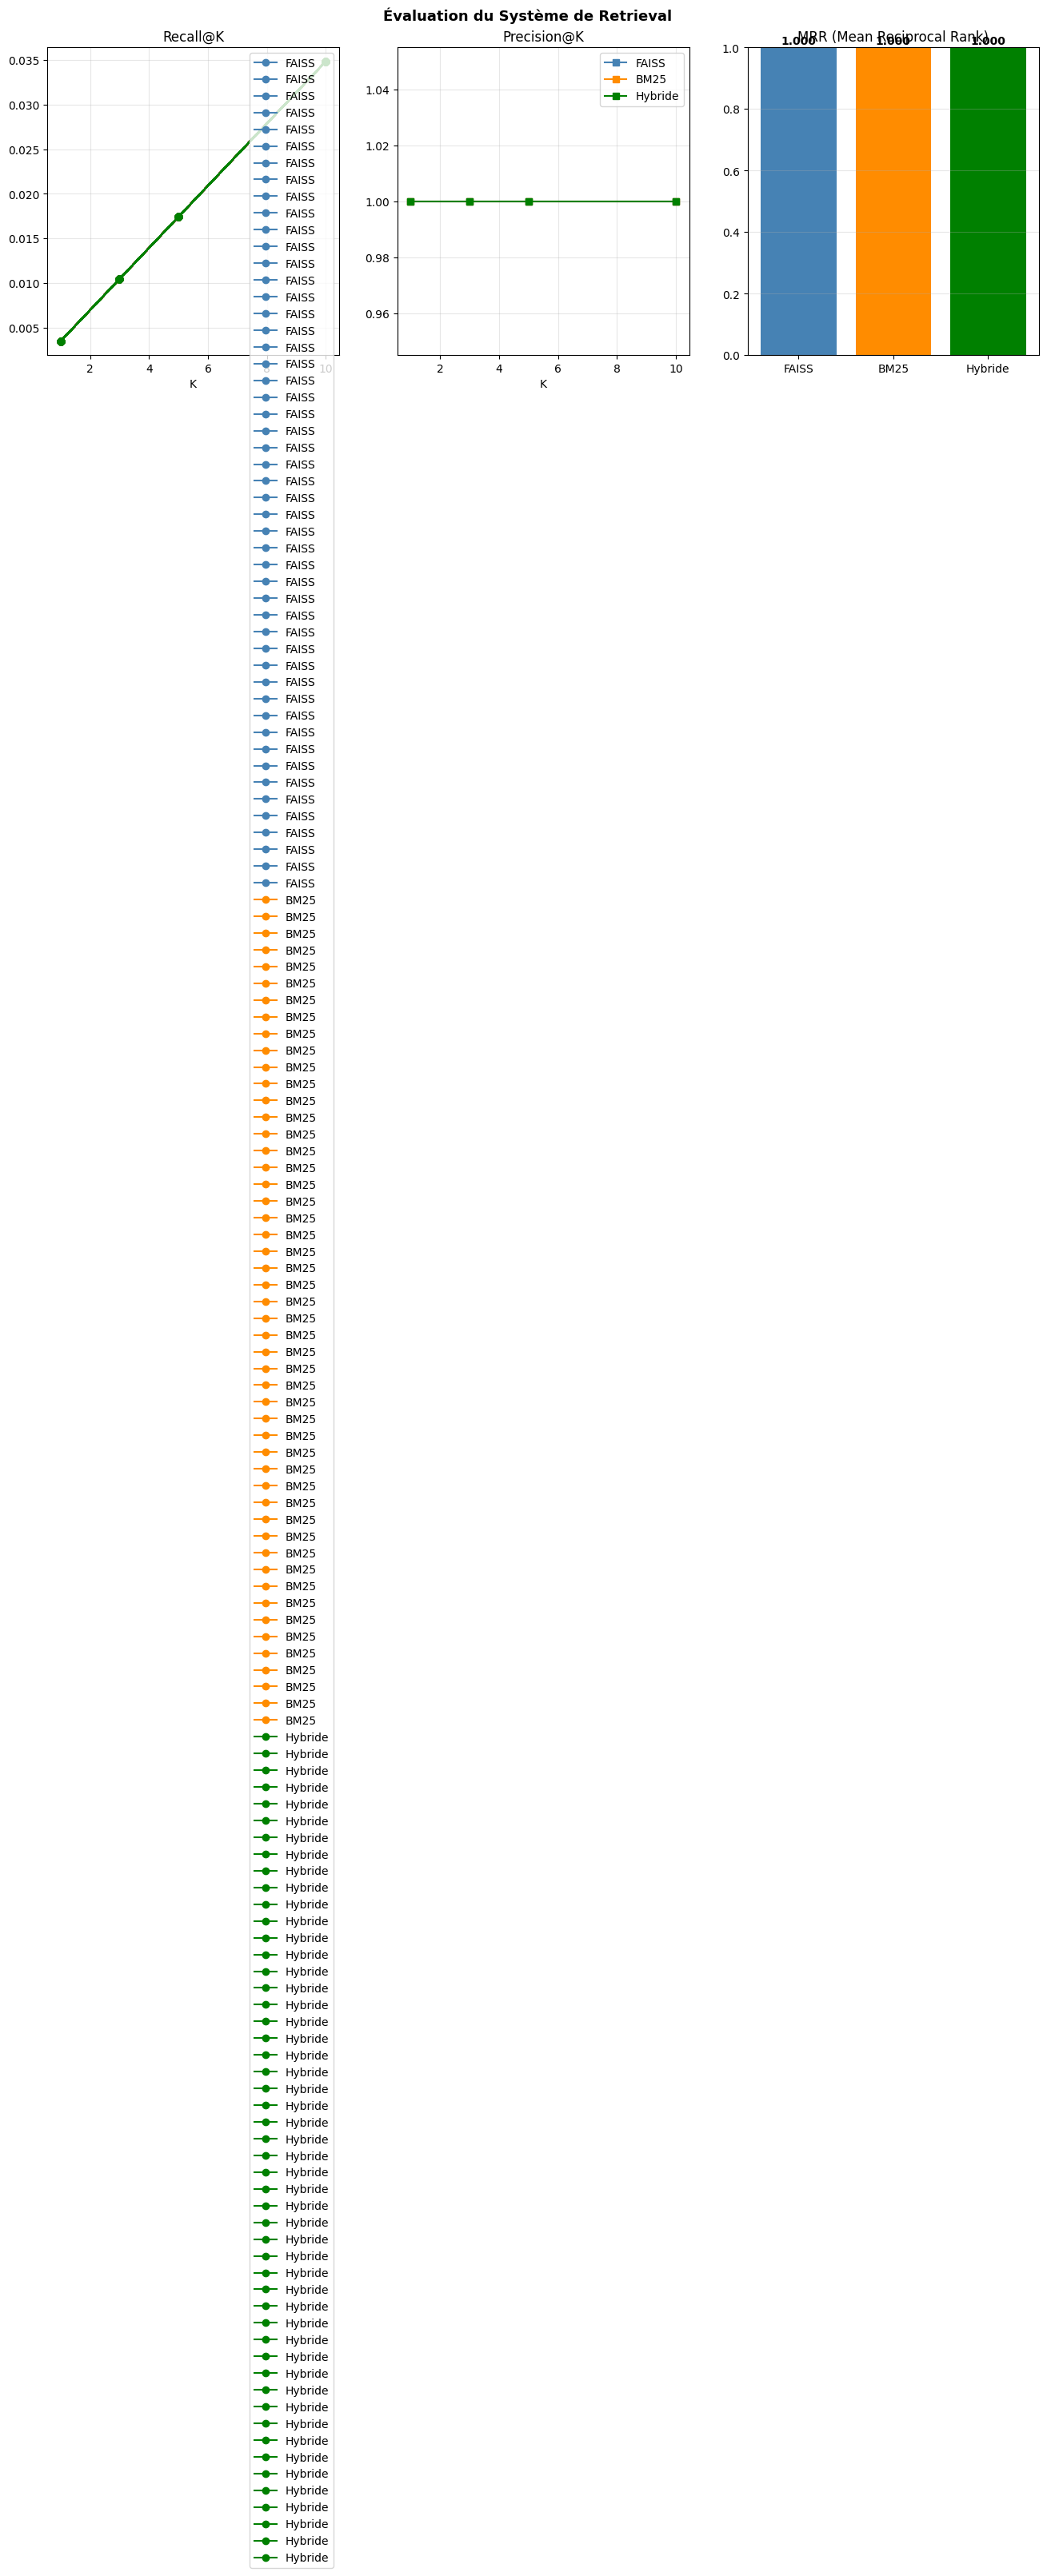

Graphique sauvegardé : evaluation_retrieval.png


In [15]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'darkorange', 'green']


for i, method in enumerate(methods):
    axes[0].plot(K_values, [eval_results[method][f'Recall@{k}'] for k in K_values],
                 marker='o', label=method, color=colors[i])
axes[0].set_title('Recall@K')
axes[0].set_xlabel('K')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, method in enumerate(methods):
    mean_prec = [np.mean(eval_results[method][f'Precision@{k}']) for k in K_values]
    axes[1].plot(K_values, mean_prec, marker='s', label=method, color=colors[i])
axes[1].set_title('Precision@K')
axes[1].set_xlabel('K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

mrr_vals = [np.mean(eval_results[m]['MRR']) for m in methods]
bars = axes[2].bar(methods, mrr_vals, color=colors)
axes[2].set_title('MRR (Mean Reciprocal Rank)')
axes[2].set_ylim(0, 1)
for bar, val in zip(bars, mrr_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Évaluation du Système de Retrieval', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_retrieval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : evaluation_retrieval.png')

In [16]:
def phishing_retrieval_pipeline(query_text, k=5, method='hybrid', alpha=0.5):

    print(f'\n Analyse : "{query_text[:80]}"')
    print(f'   Méthode : {method.upper()} | k={k}')
    print('-' * 60)

    if method == 'faiss':
        results = faiss_search(query_text, k)
    elif method == 'bm25':
        results = bm25_search(query_text, k)
    else:
        results = hybrid_search(query_text, k, alpha)

    phishing_count = sum(1 for r in results if r['label'] == 'phishing')
    risk_score = phishing_count / len(results) * 100



    print(f'\n  Score de risque estimé : {risk_score:.0f}% ({phishing_count}/{len(results)} cas phishing)')
    return results

test_queries = [
    'Your CIH Bank account is suspended. Click here to verify your identity immediately.',
    'Vous avez gagné un iPhone 15. Réclamez votre prix maintenant en cliquant ici.',
    'تحذير: تم تعليق حسابك البنكي. يرجى التحقق فوراً.',
    'Your order has been shipped and will arrive tomorrow.',  # légitime
]

for q in test_queries:
    phishing_retrieval_pipeline(q, k=5, method='hybrid')
    print()


 Analyse : "Your CIH Bank account is suspended. Click here to verify your identity immediate"
   Méthode : HYBRID | k=5
------------------------------------------------------------

  Score de risque estimé : 100% (5/5 cas phishing)


 Analyse : "Vous avez gagné un iPhone 15. Réclamez votre prix maintenant en cliquant ici."
   Méthode : HYBRID | k=5
------------------------------------------------------------

  Score de risque estimé : 100% (5/5 cas phishing)


 Analyse : "تحذير: تم تعليق حسابك البنكي. يرجى التحقق فوراً."
   Méthode : HYBRID | k=5
------------------------------------------------------------

  Score de risque estimé : 100% (5/5 cas phishing)


 Analyse : "Your order has been shipped and will arrive tomorrow."
   Méthode : HYBRID | k=5
------------------------------------------------------------

  Score de risque estimé : 0% (0/5 cas phishing)

